In [17]:
from scipy.special import perm, comb, factorial
from math import pow, pi, sqrt
from itertools import product
from matplotlib.patches import Circle, Rectangle
from numpy.random import uniform
import matplotlib.pyplot as plt
import numpy as np

### Задача 1.8
> В конкурсе по 5 номинациям участвуют 10 кинофильмов. Сколько существует вариантов распределения призов, если по каждой номинации установлены: а) различные призы; б) одинаковые призы?


In [18]:
pow(10, 5), comb(10, 5, repetition=True)

(100000, np.float64(2002.0))

### Задача 1.9
> Сколько существует семизначных чисел, состоящих из цифр 4, 5 и 6, в которых цифра 4 повторяется 3 раза, а цифры 5 и 6 - по 2 раза?


In [30]:
factorial(7) / (factorial(3) * factorial(2) * factorial(2))

np.float64(210.0)

### Задача 1.10
> Буквы Т, Е, И, Я, Р, О написаны на отдельных карточках. Ребенок берет карточки в случайном порядке и прикладывает одну к друтой: а) 3 карточки; б) все 6 карточек. Какова вероятность того, что получится слово: а) «ТОР»; б) «ТЕОРИЯ»?


In [33]:
round(1 / perm(6, 3), 4), round(1 / factorial(6), 4)

(np.float64(0.0083), np.float64(0.0014))

### Задача 1.11
> Используя условие примера 1.10, найти вероятность того, что получится слово «АНАНАС», если на отдельных карточках написаны три буквы А, две буквы Н и одна буква С.


In [34]:
round(factorial(3) * factorial(2) / factorial(6), 4)

np.float64(0.0167)

### Задача 1.16
> За круглым столом рассаживаются 5 мужчин и 5 женщин. Найти вероятность того, что: а) никакие два лица одного пола не сядут рядом; б) супруги сядут рядом, если эти мужчины и женщины образуют 5 супружеских пар.


In [36]:
round(2 * factorial(5) * factorial(5)/ factorial(10), 4), round(factorial(5) * pow(2, 5)/ factorial(10), 4)

(np.float64(0.0079), np.float64(0.0011))

### Задача 1.17
> В купейный вагон (9 купе по 4 места) семи пассажирам продано 7 билетов. Найти вероятности того, что пассажиры попали: а) в два купе; б) в семь купе; в) в три купе.


In [44]:
(round(comb(9, 2) * comb(8, 7) / comb(36, 7), 7), round(comb(9, 7) * pow(4, 7) / comb(36, 7), 4),
 round(comb(9, 3) * (comb(4, 4) * comb(4, 2) * comb(4, 1) * 6 + comb(4, 3) * comb(4, 3) * comb(4, 1) * 3 + comb(4, 3) * comb(4, 2) * comb(4, 2) * 3) / comb(36, 7), 5))

(np.float64(3.45e-05), np.float64(0.0707), np.float64(0.00773))

### Задача 1.38
> Пятитомное собрание сочинений расположено на полке в случайном порядке. Какова вероятность того, что книги стоят слева направо в порядке нумерации томов (от 1 до 5)?


In [8]:
round(1 / factorial(5), 4)

np.float64(0.0083)

### Задача 1.43
> Наудачу взятый телефонный номер состоит из 5 цифр. Какова вероятность того, что в нем все цифры: а) различные; б) одинаковые; в) нечетные? Известно, что номер телефона не начинается с цифры ноль.


In [7]:
round(9 * perm(9, 4) / (9 * pow(10, 4)), 4), round(9 / (9 * pow(10, 4)), 4), round(len(list(product('12345', repeat=5))) / (9 * pow(10, 4)), 4)

(np.float64(0.3024), 0.0001, 0.0347)

### Задача 1.48
> В старинной игре в кости необходимо было для выигрыша получить при бросании трех игральных костей сумму очков, превосходящую 10. Найти вероятности: а) выпадения l l очков; б) выигрыша.

In [9]:
len([1 for i in list(product([1, 2, 3, 4, 5, 6], repeat=3)) if sum(i) == 11]) / pow(6, 3), len([1 for i in list(product([1, 2, 3, 4, 5, 6], repeat=3)) if sum(i) > 10]) / pow(6, 3)

(0.125, 0.5)

### Тема 1. Моделирование геометрической вероятности
> Смоделируйте вычисление геометрической вероятности (на примере из лекции про метание дротиков в игровой круг, площадь которого в два раза меньше площади стены). Показать теоретический расчет и графическую иллюстрацию для рассматриваемого примера.
* Возьмём круг, площадь которого в k раз меньше площади стены: $$S_{\text{круга}} = \frac{1}{k}S_{\text{стены}}$$
Благоприятный исход - попадание в круг, поэтому: $$P(A) =\frac{S_{\text{круга}}}{S_{\text{стены}}}$$
Следовательно: $$P(A) =\frac{\frac{S_{\text{стены}}}{k}}{S_{\text{стены}}}= \frac{1}{k}$$
Таким образом, в среднем доля попадания дротиков при k = 2 равна: $$\boxed{P(A) = \frac{1}{2} = 0{,}5}$$


25.066282746310005


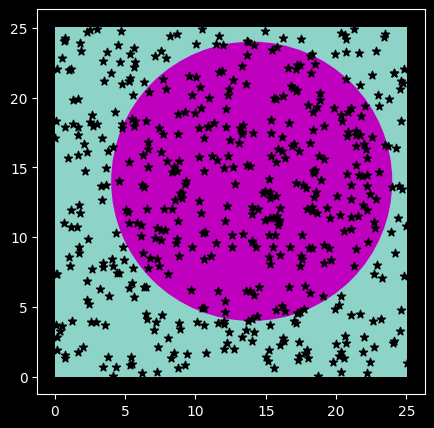

В круг попало 268 из 500 дротиков. Доля попавших составила 0.5360. В среднем доля попадания дротиков: 0.5000


In [57]:
x0, y0, R = 14, 14, 10
count, k = 500, 2
side = sqrt(k * pi * R ** 2)
print(side)
fig, ax = plt.subplots(figsize=(5, 5))
ax.add_patch(Rectangle((0, 0), side, side))
ax.add_patch(Circle((x0, y0), R, facecolor='m'))

X = uniform(0, side, count)
Y = uniform(0, side, count)
plt.scatter(X, Y, marker='*', c='black')

inside = len([d for d in (X-x0)**2 + (Y - y0)**2 if d <= R**2])
prob = inside / count

plt.show()
print(f"В круг попало {inside} из {count} дротиков. Доля попавших составила {prob:.4f}. В среднем доля попадания дротиков: {1 / k:.4f}")

### Тема 2. Моделирование связи частотного и классического определения вероятности
>Приведите пример, показывающий связь частотного и классического определения вероятности с помощью моделирования (на примере задачи про красно-синие шары или задачи о сумме очков на двух кубиках). Графически показать стремление частотной вероятности к классической при увеличении числа опытов.

* Кубики симметричны, поэтому все пары равновозможны: $$n = 6 \cdot 6 = 36$$
Событию $A$ — сумма очков равна 7 — благоприятствуют исходы $(1,6), (2,5), (3,4), (4,3), (5,2), (6,1)$, то есть $m = 6$.
По классическому определению вероятности: $$P(A) = \frac{m}{n} = \frac{6}{36} = \boxed{\frac{1}{6} \approx 0{,}1667}$$
Частотная вероятность события $A$ — доля опытов, в которых оно произошло: $$P^*(A) = \frac{m_N}{N}$$
Из моделирования видно, что при увеличении числа опытов частотная вероятность приближается к классической. Классическая вероятность — это предельный случай бесконечного числа экспериментов.

Теоретическая вероятность: 0.1667
Частотная вероятность:
n = 100 -> p = 0.1600
n = 1000 -> p = 0.1770
n = 10000 -> p = 0.1638
n = 100000 -> p = 0.1681
n = 1000000 -> p = 0.1666


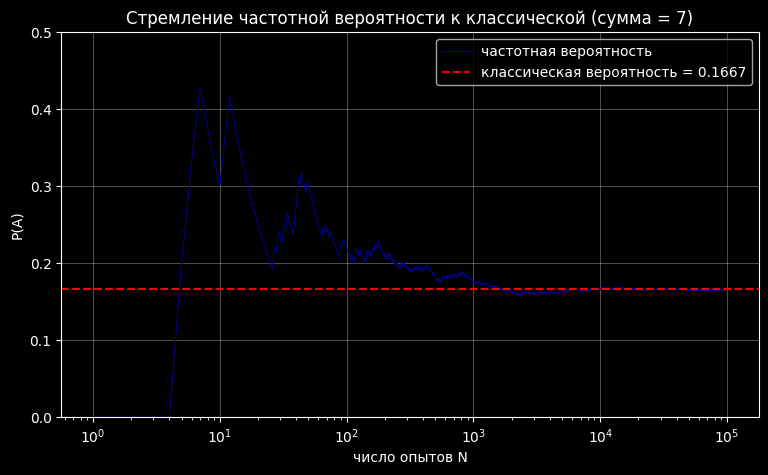

In [77]:
target = 7
rng = np.random.default_rng(42)
ls = list(product('123456', repeat=2))
prob = {}
for pair in ls:
    sum_ = sum(list(map(int, pair)))
    prob[sum_] = prob.get(sum_, 0) + 1
N = len(ls)
prob = {sum_: count / N for sum_, count in prob.items()}
P_theor, P_freq = prob[target], {}
for n in 100, 1000, 10000, 100000, 1000000:
    s = rng.integers(1, 7, n) + rng.integers(1, 7, n)
    m = int(np.sum(s == target))
    P_freq[n] = m / n
print(f"Теоретическая вероятность: {P_theor:.4f}")
print("Частотная вероятность:")
for n, p in P_freq.items():
    print(f"n = {n} -> p = {p:.4f}")
n_max = 100000
s = rng.integers(1, 7, n_max) + rng.integers(1, 7, n_max)
freq = np.cumsum(s == target) / np.arange(1, n_max + 1)
fig, ax = plt.subplots(figsize=(9, 5))
plt.plot(np.arange(1, n_max + 1), freq, lw=0.8, c='navy', label='частотная вероятность')
plt.axhline(P_theor, c='red', ls='--', label=f'классическая вероятность = {P_theor:.4f}')
plt.xscale('log')
plt.ylim(0, 0.5)
plt.xlabel('число опытов N')
plt.ylabel('P(A)')
plt.title(f'Стремление частотной вероятности к классической (сумма = {target})')
plt.legend()
plt.grid(alpha=0.3)
plt.show()